# DS-01

Clustering fundamentals: $k$-means, silhouette analysis, spectral
clustering, and DBSCAN.

**Web page:** <a href="https://apagyidavid.web.elte.hu/2025-2026-2/ds"
target="_blank">apagyidavid.web.elte.hu/2025-2026-2/ds</a>

<a target="_blank" href="https://colab.research.google.com/github/dapagyi/ds-web/blob/notebooks/ds-01.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering With $k$-Means and DBSCAN

In this notebook, we focus on practical clustering workflows using
`scikit-learn`:

- $k$-means on synthetic data,
- silhouette analysis for model selection,
- limits of linear cluster boundaries,
- spectral clustering as a nonlinear alternative,
- DBSCAN for density-based grouping.

In [1]:
import warnings

import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans, MiniBatchKMeans, SpectralClustering
from sklearn.datasets import load_sample_image, make_blobs, make_circles, make_moons
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MaxAbsScaler
from IPython.display import HTML

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(seed=333)

## A Simple $k$-Means Example

We start with a 2D dataset of four Gaussian blobs.

In [2]:
X_blobs, y_blobs_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0,
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], s=40, color="tab:blue", alpha=0.8)
ax.set_title("Unlabeled dataset")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

Now fit a $k$-means model with $k=4$.

In [3]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=0)
y_blobs_kmeans = kmeans.fit_predict(X_blobs)

h = 0.05  # Step size of the mesh (decrease for higher resolution)
x_min, x_max = X_blobs[:, 0].min() - 1, X_blobs[:, 0].max() + 1
y_min, y_max = X_blobs[:, 1].min() - 1, X_blobs[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, Z, cmap="viridis", alpha=0.2)

ax.scatter(
    X_blobs[:, 0], X_blobs[:, 1], c=y_blobs_kmeans, s=40, cmap="viridis", alpha=0.85, edgecolors="k", linewidths=0.5
)

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c="black", s=220, marker="X", alpha=0.9, edgecolors="white", linewidths=1.5)

ax.set_title("$k$-means result with Voronoi Cells ($k=4$)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

> **Intuition**
>
> The $k$-means objective balances two steps repeatedly:
>
> 1.  Assign each point to its nearest center.
> 2.  Recompute each center as the mean of its assigned points.
>
> This is an expectation-maximization style loop for a specific
> objective.

## Expectation-Maximization View of $k$-Means

Let $X = \{x_i\}_{i=1}^n$, with $x_i \in \mathbb{R}^d$, and let $k$ be
the number of clusters.

Define binary assignment variables:

$$r_{ij} =
\begin{cases}
1, & \text{if point } i \text{ is assigned to cluster } j,\\
0, & \text{otherwise.}
\end{cases}$$

The objective minimized by $k$-means is

$$J(r, \mu) = \sum_{i=1}^n \sum_{j=1}^k r_{ij}\,\|x_i - \mu_j\|_2^2,$$

subject to $\sum_{j=1}^k r_{ij} = 1$ for each $i$.

At each iteration:

- Assignment step (E-like step):
  $$r_{ij} \leftarrow 1\{j = \arg\min_{\ell} \|x_i - \mu_{\ell}\|_2^2\}$$
- Update step (M-like step):
  $$\mu_j \leftarrow \frac{\sum_i r_{ij} x_i}{\sum_i r_{ij}}$$

Each full iteration does not increase $J$.

In [4]:
def kmeans_em_history(X, n_clusters=4, random_state=0, max_iter=12):
    rng_local = np.random.default_rng(seed=random_state)
    idx = rng_local.choice(X.shape[0], size=n_clusters, replace=False)
    centers = X[idx].copy()

    history = []
    for _ in range(max_iter):
        labels = pairwise_distances_argmin(X, centers)
        history.append((centers.copy(), labels.copy()))
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(n_clusters)])

        if np.allclose(new_centers, centers):
            centers = new_centers
            labels = pairwise_distances_argmin(X, centers)
            history.append((centers.copy(), labels.copy()))
            break
        centers = new_centers

    return history

In [5]:
history = kmeans_em_history(X_blobs, n_clusters=4, random_state=1, max_iter=8)
frames_to_show = np.unique(np.linspace(0, len(history) - 1, 4, dtype=int))

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), constrained_layout=True)
for ax, step in zip(axes, frames_to_show):
    centers_step, labels_step = history[step]
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_step, cmap="viridis", s=20, alpha=0.85)
    ax.scatter(centers_step[:, 0], centers_step[:, 1], c="black", marker="X", s=150)
    ax.set_title(f"Step {step}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.show()

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame):
    ax.clear()
    centers_step, labels_step = history[frame]
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_step, cmap="viridis", s=25, alpha=0.85)
    ax.scatter(centers_step[:, 0], centers_step[:, 1], c="black", marker="X", s=200)
    ax.set_title(f"$k$-means EM steps - frame {frame}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return []

anim = FuncAnimation(fig, update, frames=len(history), interval=700, repeat=True)
plt.close(fig)
HTML(anim.to_jshtml())

Once 
 
 Loop 
 
 Reflect

## A Minimal From-Scratch Implementation

The following version is intentionally compact so that the mechanics are
easy to inspect.

In [7]:
def find_clusters(X, n_clusters, random_state=2, max_iter=300):
    rng_local = np.random.default_rng(seed=random_state)

    center_idx = rng_local.choice(X.shape[0], size=n_clusters, replace=False)
    centers = X[center_idx].copy()

    for _ in range(max_iter):
        labels = pairwise_distances_argmin(X, centers)
        new_centers = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])

        if np.allclose(new_centers, centers):
            break
        centers = new_centers

    return centers, labels

In [8]:
scratch_centers, scratch_labels = find_clusters(X_blobs, n_clusters=4, random_state=2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=scratch_labels, s=40, cmap="viridis", alpha=0.85)
ax.scatter(
    scratch_centers[:, 0],
    scratch_centers[:, 1],
    c="black",
    s=220,
    marker="X",
    alpha=0.9,
)
ax.set_title("From-scratch implementation")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

## Caveats of $k$-Means

### 1. Sensitivity to Initialization

Different initial centers can lead to different local optima.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)

for ax, seed in zip(axes, [0, 7]):
    centers_seed, labels_seed = find_clusters(X_blobs, n_clusters=4, random_state=seed)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_seed, s=35, cmap="viridis", alpha=0.85)
    ax.scatter(centers_seed[:, 0], centers_seed[:, 1], c="black", s=180, marker="X", alpha=0.9)
    ax.set_title(f"random_state={seed}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.show()

### 2. The Number of Clusters Must Be Chosen

In [10]:
labels_k6 = KMeans(n_clusters=6, n_init=10, random_state=0).fit_predict(X_blobs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_k6, s=40, cmap="viridis", alpha=0.85)
ax.set_title("$k$-means with $k=6$")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

One practical tool for selecting $k$ is silhouette analysis.

In [11]:
def silhouette_analysis(X, cluster_values, random_state=0):
    for n_clusters in cluster_values:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)

        clusterer = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        labels = clusterer.fit_predict(X)

        sil_avg = silhouette_score(X, labels)
        sil_values = silhouette_samples(X, labels)

        y_lower = 10
        for i in range(n_clusters):
            vals_i = sil_values[labels == i]
            vals_i.sort()
            size_i = vals_i.shape[0]
            y_upper = y_lower + size_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                vals_i,
                facecolor=color,
                edgecolor=color,
                alpha=0.75,
            )
            ax1.text(-0.06, y_lower + 0.5 * size_i, str(i))
            y_lower = y_upper + 10

        ax1.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.5)
        ax1.set_title(f"Silhouette plot (k={n_clusters}, avg={sil_avg:.3f})")
        ax1.set_xlabel("Silhouette coefficient")
        ax1.set_ylabel("Cluster index")
        ax1.set_xlim([-0.1, 1.0])
        ax1.set_yticks([])

        scatter_colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
        ax2.scatter(X[:, 0], X[:, 1], marker="o", s=28, c=scatter_colors, alpha=0.8, edgecolors="none")
        cluster_centers = clusterer.cluster_centers_
        ax2.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker="X", c="black", s=200)
        ax2.set_title("Clustered data")
        ax2.set_xlabel("Feature 1")
        ax2.set_ylabel("Feature 2")

        plt.show()

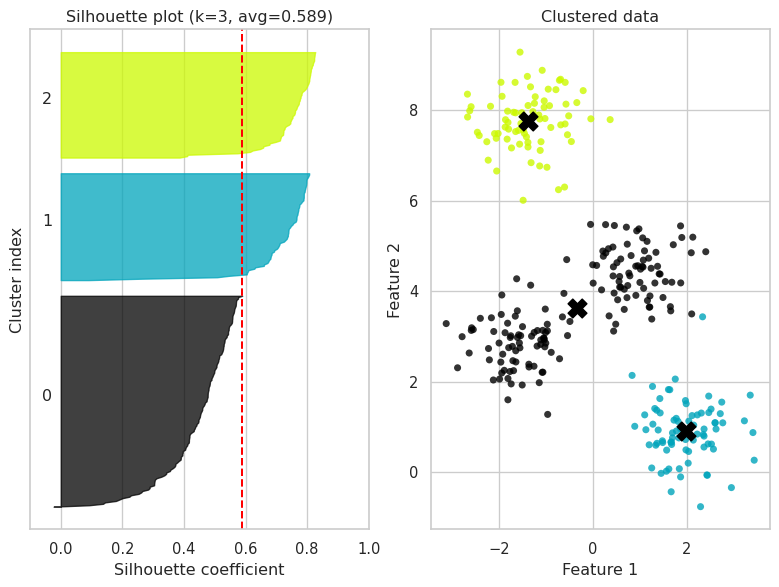

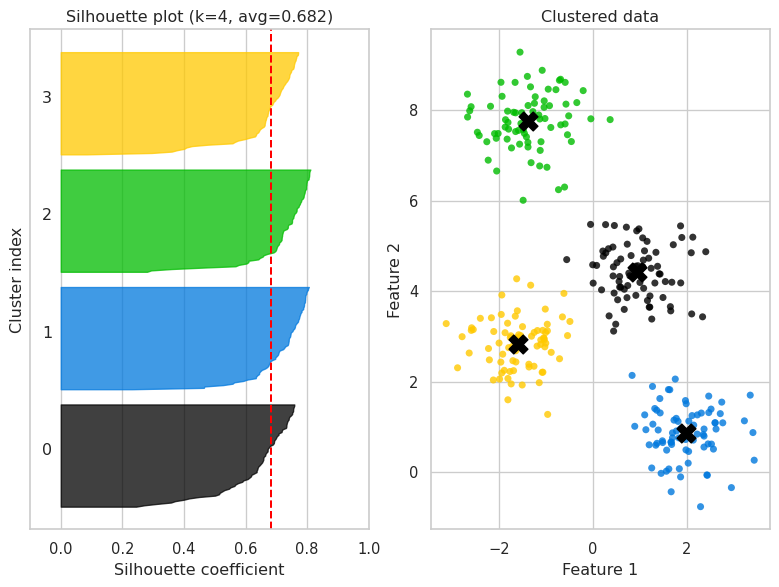

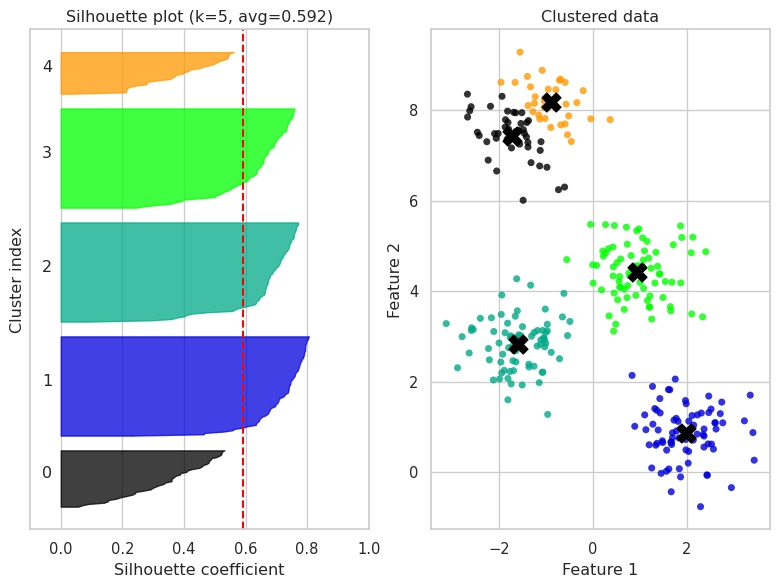

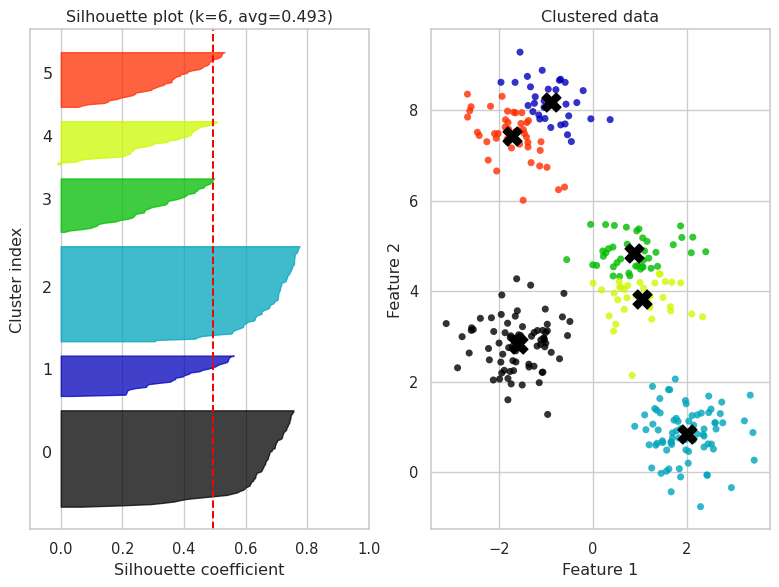

In [12]:
silhouette_analysis(X_blobs, cluster_values=[3, 4, 5, 6], random_state=0)

## Nonlinear Shapes: Where $k$-Means Struggles

In [13]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.05, random_state=0)
labels_moons_kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit_predict(X_moons)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons_kmeans, s=40, cmap="viridis", alpha=0.85)
ax.set_title("$k$-means on moons")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

For such geometries, a graph-based approach can be more suitable.

In [14]:
spectral_model = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    assign_labels="kmeans",
    random_state=0,
)
labels_moons_spectral = spectral_model.fit_predict(X_moons)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons_spectral, s=40, cmap="viridis", alpha=0.85)
ax.set_title("Spectral clustering on moons")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

/home/runner/work/ds-web/ds-web/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(

## Color Compression With MiniBatch $k$-Means

In [15]:
def quantize_image(img, n_colors, random_state=0):
    pixels = (img / 255.0).reshape(-1, 3)
    model = MiniBatchKMeans(n_clusters=n_colors, random_state=random_state, n_init=5)
    labels = model.fit_predict(pixels)
    quantized = model.cluster_centers_[labels].reshape(img.shape)
    label_map = labels.reshape(img.shape[:2])
    return quantized, label_map

In [16]:
def plot_pixels(data, title, colors=None, n_samples=10_000, seed=0):
    if colors is None:
        colors = data

    rng_local = np.random.default_rng(seed=seed)
    idx = rng_local.choice(data.shape[0], size=min(n_samples, data.shape[0]), replace=False)
    sampled = data[idx]
    sampled_colors = colors[idx]

    r, g, b = sampled.T
    fig, axes = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)

    axes[0].scatter(r, g, c=sampled_colors, marker=".", s=8)
    axes[0].set_title("Red-Green")
    axes[0].set_xlabel("Red")
    axes[0].set_ylabel("Green")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)

    axes[1].scatter(r, b, c=sampled_colors, marker=".", s=8)
    axes[1].set_title("Red-Blue")
    axes[1].set_xlabel("Red")
    axes[1].set_ylabel("Blue")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

    fig.suptitle(title)
    plt.show()

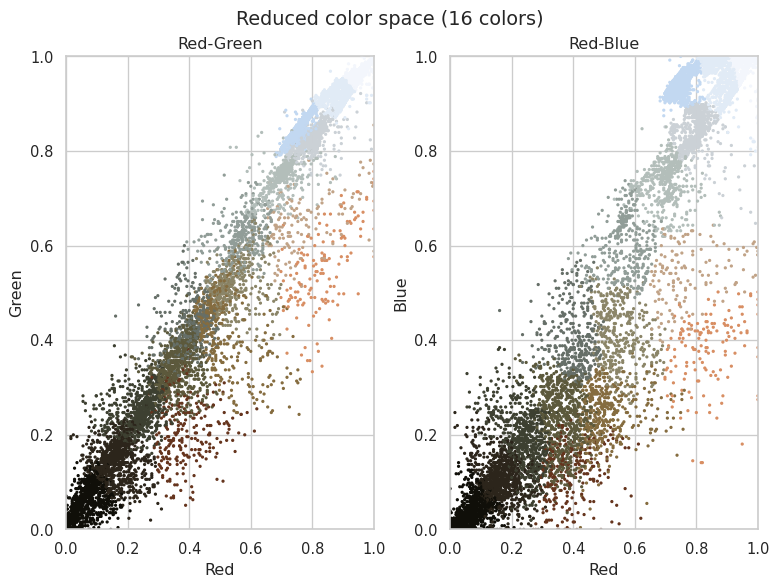

In [17]:
warnings.simplefilter("ignore")

china = load_sample_image("china.jpg")
pixel_data = (china / 255.0).reshape(-1, 3)
plot_pixels(pixel_data, title="Input color space")

mb_kmeans = MiniBatchKMeans(n_clusters=16, random_state=0, n_init=5)
mb_kmeans.fit(pixel_data)
compressed_colors = mb_kmeans.cluster_centers_[mb_kmeans.predict(pixel_data)]

plot_pixels(pixel_data, title="Reduced color space (16 colors)", colors=compressed_colors)

In [18]:
china = load_sample_image("china.jpg")
flower = load_sample_image("flower.jpg")

palette_sizes = [4, 8, 16, 32]

fig, axes = plt.subplots(2, len(palette_sizes) + 1, figsize=(14, 6), constrained_layout=True)

axes[0, 0].imshow(china)
axes[0, 0].set_title("china: original")
axes[0, 0].set_axis_off()

axes[1, 0].imshow(flower)
axes[1, 0].set_title("flower: original")
axes[1, 0].set_axis_off()

for j, n_colors in enumerate(palette_sizes, start=1):
    q_china, _ = quantize_image(china, n_colors=n_colors, random_state=0)
    q_flower, _ = quantize_image(flower, n_colors=n_colors, random_state=0)

    axes[0, j].imshow(q_china)
    axes[0, j].set_title(f"{n_colors} colors")
    axes[0, j].set_axis_off()

    axes[1, j].imshow(q_flower)
    axes[1, j].set_title(f"{n_colors} colors")
    axes[1, j].set_axis_off()

plt.show()

In [19]:
q8, labels8 = quantize_image(china, n_colors=8, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].imshow(q8)
axes[0].set_title("Quantized image (8 colors)")
axes[0].set_axis_off()

im = axes[1].imshow(labels8, cmap="tab20")
axes[1].set_title("Segment labels")
axes[1].set_axis_off()
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()

## Density-Based Clustering (DBSCAN)

To compare with centroid-based methods, we build a synthetic dataset
with mixed cluster geometry.

In [20]:
blobs_x, _ = make_blobs(n_samples=400, centers=2, cluster_std=1.3, random_state=333)
circle_x, _ = make_circles(n_samples=300, noise=0.09, factor=0.3, random_state=333)
moon_x, _ = make_moons(n_samples=300, noise=0.07, random_state=333)

X_mix = np.concatenate([blobs_x, 3 * moon_x + 9, 3 * circle_x - 13], axis=0)
X_mix[:, 1] = X_mix[:, 1] / 7
rng.shuffle(X_mix)


def visualize_clusters(X, labels=None, cluster_centers=None, title=""):
    fig, ax = plt.subplots(figsize=(8, 6))

    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], s=12, color="tab:blue", alpha=0.85)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=12, c=labels, cmap="viridis", alpha=0.85)

    if cluster_centers is not None:
        ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c="black", s=220, marker="X", alpha=0.9)

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    plt.show()

In [21]:
visualize_clusters(X_mix, title="Composite dataset")

### Revisiting $k$-Means

In [22]:
kmeans_mix = KMeans(n_clusters=4, n_init=10, random_state=333)
labels_mix_kmeans = kmeans_mix.fit_predict(X_mix)
visualize_clusters(X_mix, labels_mix_kmeans, kmeans_mix.cluster_centers_, title="$k$-means ($k=4$)")

### Normalization

In [23]:
scaler = MaxAbsScaler()
X_mix_scaled = scaler.fit_transform(X_mix)

kmeans_mix_scaled = KMeans(n_clusters=6, n_init=10, random_state=333)
labels_mix_scaled = kmeans_mix_scaled.fit_predict(X_mix_scaled)
centers_original_scale = scaler.inverse_transform(kmeans_mix_scaled.cluster_centers_)

visualize_clusters(
    X_mix,
    labels_mix_scaled,
    centers_original_scale,
    title="$k$-means on normalized data ($k=6$)",
)

Even with normalization and a better choice of $k$, centroid-based
partitioning can remain inadequate for arbitrary shapes.

### DBSCAN on Raw and Normalized Data

In [24]:
labels_dbscan_raw = DBSCAN().fit_predict(X_mix)
visualize_clusters(X_mix, labels_dbscan_raw, title="DBSCAN (raw data)")

In [25]:
labels_dbscan_scaled = DBSCAN().fit_predict(X_mix_scaled)
visualize_clusters(X_mix, labels_dbscan_scaled, title="DBSCAN (normalized data)")

### Tuning `eps`

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), constrained_layout=True)

for ax, eps in zip(axes, [0.10, 0.05, 0.03]):
    labels_eps = DBSCAN(eps=eps, min_samples=8).fit_predict(X_mix_scaled)
    ax.scatter(X_mix[:, 0], X_mix[:, 1], s=10, c=labels_eps, cmap="viridis", alpha=0.85)
    ax.set_title(f"DBSCAN, eps={eps}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.show()

To estimate a meaningful `eps` range, inspect the $k$-distance curve.

In [27]:
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_mix_scaled)
distances, _ = neighbors_fit.kneighbors(X_mix_scaled)

k_distances = np.sort(distances[:, k - 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(k_distances, color="tab:blue")
ax.set_title(f"$k$-distance graph (k={k})")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel("$k$-distance")
plt.show()

In [28]:
labels_dbscan_tuned = DBSCAN(eps=0.04).fit_predict(X_mix_scaled)
visualize_clusters(X_mix, labels_dbscan_tuned, title="DBSCAN (normalized data, eps=0.04)")

## Hierarchical Clustering Demo

In [29]:
agglo = AgglomerativeClustering(n_clusters=6, linkage="ward")
labels_agglo = agglo.fit_predict(X_mix_scaled)

sample_idx = rng.choice(X_mix_scaled.shape[0], size=200, replace=False)
Z = linkage(X_mix_scaled[sample_idx], method="ward")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
axes[0].scatter(X_mix[:, 0], X_mix[:, 1], c=labels_agglo, s=10, cmap="viridis", alpha=0.85)
axes[0].set_title("Agglomerative clustering (ward, k=6)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

dendrogram(Z, no_labels=True, color_threshold=None, ax=axes[1])
axes[1].set_title("Dendrogram (subset of 200 points)")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Linkage distance")

plt.show()

# Homework

Check
<span class="badge text-bg-warning me-1">HW/1</span><a href="https://apagyidavid.web.elte.hu/2025-2026-2/ds/notebooks/ds-hw-01" target="_blank">Clustering</a>
for details.

**Deadline:** 2026. 04. 09. 23:59

# Attribution

Some of the original ideas and examples used in this session were
adapted from:

- Jake VanderPlas, *Python Data Science Handbook*, clustering chapter.
- The corresponding public notebook repository:
  <a href="https://github.com/jakevdp/PythonDataScienceHandbook"
  target="_blank">github.com/jakevdp/PythonDataScienceHandbook</a>